In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
#Import Packages
import pandas as pd
import seaborn as sns
import numpy as np

import time
import sys
import matplotlib.pyplot as plt
import math
import os

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans

In [5]:
!git clone https://github.com/HickeyLab/Hierarchical-Tissue-Unit-Annotation.git

Cloning into 'Hierarchical-Tissue-Unit-Annotation'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 59 (delta 21), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 19.35 MiB | 11.31 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [6]:
#Import Neighborhood Functions and Code
cellhier_path = 'Hierarchical-Tissue-Unit-Annotation/'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

ModuleNotFoundError: No module named 'cellhier'

In [7]:
# Initialize list to hold DataFrames
dfs1 = []
dfs2 = []
dfs3 = []
dfs4 = []

# Loop through all 31 files
for i in range(1, 32):  # range is exclusive at the end
    file_path = f"drive/MyDrive/bottom/{i}.csv"
    # Read the CSV file
    df = pd.read_csv(file_path)
    # Append to list
    dfs1.append(df)
    file_path = f"drive/MyDrive/top/{i}.csv"
    # Read the CSV file
    df = pd.read_csv(file_path)
    # Append to list
    dfs2.append(df)
    file_path = f"drive/MyDrive/new/{i}.csv"
    # Read the CSV file
    df = pd.read_csv(file_path)
    # Append to list
    dfs3.append(df)
    file_path = f"drive/MyDrive/disco/{i}.csv"
    # Read the CSV file
    df = pd.read_csv(file_path)
    # Append to list
    dfs4.append(df)



# Concatenate all DataFrames into one
cells1 = pd.concat(dfs1, ignore_index=True)
cells2 = pd.concat(dfs2, ignore_index=True)
cells3 = pd.concat(dfs3, ignore_index=True)
cells4 = pd.concat(dfs4, ignore_index=True)

In [ ]:
cells1.shape

(321563, 4)

In [ ]:
cells2.shape

(301558, 4)

In [ ]:
cells3.shape

(290714, 4)

In [ ]:
cells4.shape

(578428, 4)

In [8]:
cells1['unique_region'] = cells1['unique_region'].astype(str)
cells1['Cell Type'] = cells1['Cell Type'].astype(str)
cells1.reset_index(inplace=True, drop=True)

cells2['unique_region'] = cells2['unique_region'].astype(str)
cells2['Cell Type'] = cells2['Cell Type'].astype(str)
cells2.reset_index(inplace=True, drop=True)

cells3['unique_region'] = cells3['unique_region'].astype(str)
cells3['Cell Type'] = cells3['Cell Type'].astype(str)
cells3.reset_index(inplace=True, drop=True)

cells4['unique_region'] = cells4['unique_region'].astype(str)
cells4['Cell Type'] = cells4['Cell Type'].astype(str)
cells4.reset_index(inplace=True, drop=True)


In [ ]:
cells1['Cell Type'].unique()

array(['TA', 'Enterocyte', 'Endothelial', 'Stroma', 'CD8+ T', 'Paneth',
       'CD4+ T cell', 'Smooth muscle', 'M2 Macrophage', 'Neuroendocrine',
       'Nerve', 'Goblet', 'Lymphatic', 'ICC', 'Plasma',
       'CD66+ Enterocyte', 'Cycling TA', 'Neutrophil', 'M1 Macrophage',
       'B', 'CD7+ Immune', 'DC', 'NK', 'MUC1+ Enterocyte',
       'CD57+ Enterocyte'], dtype=object)

In [9]:
#Function for getting neighborhood windows

def get_windows(job, n_neighbors, exps, tissue_group):

    # Unpack the job tuple containing start_time, idx, tissue_name, and indices
    start_time, idx, tissue_name, indices = job

    # Record the current time to measure the duration of the job
    job_start = time.time()

    # Print a message indicating the start of the job
    print("Starting:", str(idx+1)+'/'+str(len(exps)), ': ' + exps[idx])

    # Get the subset of the dataset for the specific tissue
    tissue = tissue_group.get_group(tissue_name)

    # Extract the coordinates (X, Y) for the points to be fitted from the tissue subset
    to_fit = tissue.loc[indices][[X, Y]].values

    # Fit the NearestNeighbors model on the tissue's X, Y coordinates
    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X, Y]].values)

    # Find the nearest neighbors for the points in 'to_fit'
    m = fit.kneighbors(to_fit)

    # Sort the neighbors
    # 'args' are the indices that would sort the distances
    args = m[0].argsort(axis=1)

    # 'add' is used to adjust indices for flattened array
    add = np.arange(m[1].shape[0]) * m[1].shape[1]

    # Calculate sorted indices for neighbors
    sorted_indices = m[1].flatten()[args + add[:, None]]

    # Retrieve the neighbor indices from the tissue dataset
    neighbors = tissue.index.values[sorted_indices]

    # Record the end time of the job
    end_time = time.time()

    # Print a message indicating the end of the job and the duration
    print("Finishing:", str(idx+1)+"/"+str(len(exps)), ": "+ exps[idx], end_time - job_start, end_time - start_time)

    # Return the neighbor indices as an array of integers
    return neighbors.astype(np.int32)


# Define column names that will be used for neighborhood analysis
X = 'x'                  # Variable for the X coordinate
Y = 'y'                  # Variable for the Y coordinate
reg = 'unique_region'         # Variable for the filename or region identifier associated with coordinates
cluster_col = 'Cell Type'  # Variable for cell type/subtype classification

# List of columns to keep for analysis
keep_cols = [X, Y, reg, cluster_col]

# Concatenate the original 'cells' DataFrame with dummy variables created from 'cluster_col'
# pd.get_dummies() converts categorical variable(s) into dummy/indicator variables
cells1 = pd.concat([cells1, pd.get_dummies(cells1[cluster_col], dtype=int)], axis=1)
# Get unique values from the 'cluster_col' column to use for summarization
sum_cols1 = cells1[cluster_col].unique()
values1 = cells1[sum_cols1].values
ks = [5,10,20] # k=5 means it collects 5 nearest neighbors for each center cell
n_neighbors = max(ks) #sets n_neighbors to max of the list that is set
tissue_group1 = cells1[[X, Y, reg]].groupby(reg)
exps1 = list(cells1[reg].unique())
tissue_chunks1 = [(time.time(), exps1.index(t), t, a) for t, indices in tissue_group1.groups.items() for a in np.array_split(indices, 1)]
tissues1 = [get_windows(job, n_neighbors, exps1, tissue_group1) for job in tissue_chunks1]


cells2 = pd.concat([cells2, pd.get_dummies(cells2[cluster_col], dtype=int)], axis=1)
# Get unique values from the 'cluster_col' column to use for summarization
sum_cols2 = cells2[cluster_col].unique()
values2 = cells2[sum_cols2].values
tissue_group2 = cells2[[X, Y, reg]].groupby(reg)
exps2 = list(cells2[reg].unique())
tissue_chunks2 = [(time.time(), exps2.index(t), t, a) for t, indices in tissue_group2.groups.items() for a in np.array_split(indices, 1)]
tissues2 = [get_windows(job, n_neighbors, exps2, tissue_group2) for job in tissue_chunks2]


cells3 = pd.concat([cells3, pd.get_dummies(cells3[cluster_col], dtype=int)], axis=1)
# Get unique values from the 'cluster_col' column to use for summarization
sum_cols3 = cells3[cluster_col].unique()
values3 = cells3[sum_cols3].values
tissue_group3 = cells3[[X, Y, reg]].groupby(reg)
exps3 = list(cells3[reg].unique())
tissue_chunks3 = [(time.time(), exps3.index(t), t, a) for t, indices in tissue_group3.groups.items() for a in np.array_split(indices, 1)]
tissues3 = [get_windows(job, n_neighbors, exps3, tissue_group3) for job in tissue_chunks3]


cells4 = pd.concat([cells4, pd.get_dummies(cells4[cluster_col], dtype=int)], axis=1)
# Get unique values from the 'cluster_col' column to use for summarization
sum_cols4 = cells4[cluster_col].unique()
values4 = cells4[sum_cols4].values
tissue_group4 = cells4[[X, Y, reg]].groupby(reg)
exps4 = list(cells4[reg].unique())
tissue_chunks4 = [(time.time(), exps4.index(t), t, a) for t, indices in tissue_group4.groups.items() for a in np.array_split(indices, 1)]
tissues4 = [get_windows(job, n_neighbors, exps4, tissue_group4) for job in tissue_chunks4]




Starting: 1/31 : 1
Finishing: 1/31 : 1 0.050841569900512695 0.05394887924194336
Starting: 10/31 : 10
Finishing: 10/31 : 10 0.045601844787597656 0.09969902038574219
Starting: 11/31 : 11
Finishing: 11/31 : 11 0.041101694107055664 0.1409168243408203
Starting: 12/31 : 12
Finishing: 12/31 : 12 0.040574073791503906 0.18164849281311035
Starting: 13/31 : 13
Finishing: 13/31 : 13 0.025698184967041016 0.20749759674072266
Starting: 14/31 : 14
Finishing: 14/31 : 14 0.026113033294677734 0.23375797271728516
Starting: 15/31 : 15
Finishing: 15/31 : 15 0.025482892990112305 0.25934362411499023
Starting: 16/31 : 16
Finishing: 16/31 : 16 0.025254011154174805 0.28470897674560547
Starting: 17/31 : 17
Finishing: 17/31 : 17 0.08738040924072266 0.3721940517425537
Starting: 18/31 : 18
Finishing: 18/31 : 18 0.0747690200805664 0.4472835063934326
Starting: 19/31 : 19
Finishing: 19/31 : 19 0.07318544387817383 0.5210578441619873
Starting: 2/31 : 2
Finishing: 2/31 : 2 0.02521991729736328 0.5466783046722412
Starting: 

In [ ]:
len(tissues1)
tissues1[0].shape

(4271, 20)

In [ ]:
len(tissues2)
tissues2[0].shape

(3769, 20)

In [ ]:
len(tissues3)
tissues3[0].shape

(3722, 20)

In [ ]:
len(tissues4)
tissues4[0].shape

(7479, 20)

In [10]:
# Initialize a dictionary to store the output
out_dict1 = {}

# Loop over a list of values 'ks' (different numbers of neighbors to consider)
for k in ks:
    # Iterate over each tissue's neighbors and the corresponding job information
    for neighbors, job in zip(tissues1, tissue_chunks1):

        # Create an array of indices for the current chunk of data
        chunk = np.arange(len(neighbors))  # equivalent to 0, 1, 2, ..., len(neighbors)-1

        # Extract the tissue name and indices from the job tuple
        tissue_name = job[2]  # Region/filename from the job tuple
        indices = job[3]      # Indices from the job tuple

        # Compute the 'window' - a summary measure for the neighborhood of each cell up to the k-th neighbor
        # Reshape and sum values to get counts of the unique cell type for each cell index
        window = values1[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(sum_cols1)).sum(axis=1)

        # Store the computed window and indices in the output dictionary
        # Keyed by a tuple of (tissue_name, k)
        out_dict1[(tissue_name, k)] = (window.astype(np.float16), indices)

# Initialize a dictionary to store the final windows data
windows_1 = {}

# Iterate over each value of k again to process the stored information
for k in ks:

    # Concatenate data for each experiment ('exp') into a DataFrame
    # This DataFrame contains the window data for each cell, indexed by cell indices, for the current value of k
    window = pd.concat([pd.DataFrame(out_dict1[(exp, k)][0], index=out_dict1[(exp, k)][1].astype(int), columns=sum_cols1) for exp in exps1], axis=0)

    # Ensure the window data is in the same order as the original cells DataFrame
    window = window.loc[cells1.index.values]

    # Concatenate the window data with the original columns specified in 'keep_cols'
    window = pd.concat([cells1[keep_cols], window], axis=1)

    # Store the concatenated DataFrame in the 'windows' dictionary, keyed by the current value of k
    windows_1[k] = window

In [11]:
# Initialize a dictionary to store the output
out_dict2 = {}

# Loop over a list of values 'ks' (different numbers of neighbors to consider)
for k in ks:
    # Iterate over each tissue's neighbors and the corresponding job information
    for neighbors, job in zip(tissues2, tissue_chunks2):

        # Create an array of indices for the current chunk of data
        chunk = np.arange(len(neighbors))  # equivalent to 0, 1, 2, ..., len(neighbors)-1

        # Extract the tissue name and indices from the job tuple
        tissue_name = job[2]  # Region/filename from the job tuple
        indices = job[3]      # Indices from the job tuple

        # Compute the 'window' - a summary measure for the neighborhood of each cell up to the k-th neighbor
        # Reshape and sum values to get counts of the unique cell type for each cell index
        window = values2[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(sum_cols2)).sum(axis=1)

        # Store the computed window and indices in the output dictionary
        # Keyed by a tuple of (tissue_name, k)
        out_dict2[(tissue_name, k)] = (window.astype(np.float16), indices)

# Initialize a dictionary to store the final windows data
windows_2 = {}

# Iterate over each value of k again to process the stored information
for k in ks:

    # Concatenate data for each experiment ('exp') into a DataFrame
    # This DataFrame contains the window data for each cell, indexed by cell indices, for the current value of k
    window = pd.concat([pd.DataFrame(out_dict2[(exp, k)][0], index=out_dict2[(exp, k)][1].astype(int), columns=sum_cols2) for exp in exps2], axis=0)

    # Ensure the window data is in the same order as the original cells DataFrame
    window = window.loc[cells2.index.values]

    # Concatenate the window data with the original columns specified in 'keep_cols'
    window = pd.concat([cells2[keep_cols], window], axis=1)

    # Store the concatenated DataFrame in the 'windows' dictionary, keyed by the current value of k
    windows_2[k] = window

In [12]:
# Initialize a dictionary to store the output
out_dict3 = {}

# Loop over a list of values 'ks' (different numbers of neighbors to consider)
for k in ks:
    # Iterate over each tissue's neighbors and the corresponding job information
    for neighbors, job in zip(tissues3, tissue_chunks3):

        # Create an array of indices for the current chunk of data
        chunk = np.arange(len(neighbors))  # equivalent to 0, 1, 2, ..., len(neighbors)-1

        # Extract the tissue name and indices from the job tuple
        tissue_name = job[2]  # Region/filename from the job tuple
        indices = job[3]      # Indices from the job tuple

        # Compute the 'window' - a summary measure for the neighborhood of each cell up to the k-th neighbor
        # Reshape and sum values to get counts of the unique cell type for each cell index
        window = values3[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(sum_cols3)).sum(axis=1)

        # Store the computed window and indices in the output dictionary
        # Keyed by a tuple of (tissue_name, k)
        out_dict3[(tissue_name, k)] = (window.astype(np.float16), indices)

# Initialize a dictionary to store the final windows data
windows_3 = {}

# Iterate over each value of k again to process the stored information
for k in ks:

    # Concatenate data for each experiment ('exp') into a DataFrame
    # This DataFrame contains the window data for each cell, indexed by cell indices, for the current value of k
    window = pd.concat([pd.DataFrame(out_dict3[(exp, k)][0], index=out_dict3[(exp, k)][1].astype(int), columns=sum_cols3) for exp in exps3], axis=0)

    # Ensure the window data is in the same order as the original cells DataFrame
    window = window.loc[cells3.index.values]

    # Concatenate the window data with the original columns specified in 'keep_cols'
    window = pd.concat([cells3[keep_cols], window], axis=1)

    # Store the concatenated DataFrame in the 'windows' dictionary, keyed by the current value of k
    windows_3[k] = window

In [13]:
# Initialize a dictionary to store the output
out_dict4 = {}

# Loop over a list of values 'ks' (different numbers of neighbors to consider)
for k in ks:
    # Iterate over each tissue's neighbors and the corresponding job information
    for neighbors, job in zip(tissues4, tissue_chunks4):

        # Create an array of indices for the current chunk of data
        chunk = np.arange(len(neighbors))  # equivalent to 0, 1, 2, ..., len(neighbors)-1

        # Extract the tissue name and indices from the job tuple
        tissue_name = job[2]  # Region/filename from the job tuple
        indices = job[3]      # Indices from the job tuple

        # Compute the 'window' - a summary measure for the neighborhood of each cell up to the k-th neighbor
        # Reshape and sum values to get counts of the unique cell type for each cell index
        window = values4[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(sum_cols4)).sum(axis=1)

        # Store the computed window and indices in the output dictionary
        # Keyed by a tuple of (tissue_name, k)
        out_dict4[(tissue_name, k)] = (window.astype(np.float16), indices)

# Initialize a dictionary to store the final windows data
windows_4 = {}

# Iterate over each value of k again to process the stored information
for k in ks:

    # Concatenate data for each experiment ('exp') into a DataFrame
    # This DataFrame contains the window data for each cell, indexed by cell indices, for the current value of k
    window = pd.concat([pd.DataFrame(out_dict4[(exp, k)][0], index=out_dict4[(exp, k)][1].astype(int), columns=sum_cols4) for exp in exps4], axis=0)

    # Ensure the window data is in the same order as the original cells DataFrame
    window = window.loc[cells4.index.values]

    # Concatenate the window data with the original columns specified in 'keep_cols'
    window = pd.concat([cells4[keep_cols], window], axis=1)

    # Store the concatenated DataFrame in the 'windows' dictionary, keyed by the current value of k
    windows_4[k] = window

In [14]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2_1 = windows_1[k]
#Add cell type column to output windows dataframe
windows2_1[cluster_col] = cells1[cluster_col]
windows2_1

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,x,y,unique_region,Cell Type,TA,Enterocyte,Endothelial,Stroma,CD8+ T,Paneth,...,CD66+ Enterocyte,Cycling TA,Neutrophil,M1 Macrophage,B,CD7+ Immune,DC,NK,MUC1+ Enterocyte,CD57+ Enterocyte
0,159,0,1,TA,2.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,169,0,1,Enterocyte,3.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,187,0,1,Enterocyte,3.0,4.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,190,0,1,Endothelial,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,193,0,1,Stroma,0.0,3.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321558,487,127,31,MUC1+ Enterocyte,0.0,2.0,0.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
321559,492,127,31,Enterocyte,0.0,2.0,0.0,0.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
321560,493,127,31,NK,0.0,1.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
321561,494,127,31,Goblet,0.0,1.0,0.0,0.0,0.0,0.0,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [15]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2_2 = windows_2[k]
#Add cell type column to output windows dataframe
windows2_2[cluster_col] = cells2[cluster_col]
windows2_2

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,x,y,unique_region,Cell Type,ICC,Enterocyte,Lymphatic,Endothelial,M2 Macrophage,Stroma,...,CD66+ Enterocyte,Plasma,CD7+ Immune,DC,NK,Neutrophil,M1 Macrophage,B,MUC1+ Enterocyte,CD57+ Enterocyte
0,175,0,1,ICC,1.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,176,0,1,Enterocyte,1.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,177,0,1,Enterocyte,1.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,178,0,1,Enterocyte,1.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,185,0,1,Lymphatic,0.0,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301553,445,127,31,Nerve,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
301554,454,127,31,CD66+ Enterocyte,0.0,3.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
301555,455,127,31,TA,0.0,3.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
301556,456,127,31,CD8+ T,0.0,2.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2_3 = windows_3[k]
#Add cell type column to output windows dataframe
windows2_3[cluster_col] = cells3[cluster_col]
windows2_3

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,x,y,unique_region,Cell Type,Smooth muscle,B,Enterocyte,Cycling TA,M2 Macrophage,DC,...,NK,M1 Macrophage,CD8+ T,Endothelial,Goblet,CD57+ Enterocyte,Neutrophil,ICC,Neuroendocrine,MUC1+ Enterocyte
0,217,0,1,Smooth muscle,1.0,1.0,5.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,221,0,1,B,0.0,1.0,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,223,0,1,Enterocyte,0.0,1.0,7.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,224,0,1,Enterocyte,0.0,1.0,5.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,252,0,1,Cycling TA,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353627,449,127,31,NK,0.0,0.0,4.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
353628,453,127,31,ICC,0.0,0.0,3.0,2.0,2.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
353629,454,127,31,CD8+ T,0.0,0.0,3.0,1.0,3.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
353630,456,127,31,M2 Macrophage,0.0,0.0,4.0,0.0,3.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [17]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2_4 = windows_4[k]
#Add cell type column to output windows dataframe
windows2_4[cluster_col] = cells4[cluster_col]
windows2_4

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,x,y,unique_region,Cell Type,Neutrophil,Smooth muscle,CD8+ T,Cycling TA,MUC1+ Enterocyte,Enterocyte,...,Plasma,CD7+ Immune,Neuroendocrine,Nerve,ICC,M2 Macrophage,CD4+ T cell,M1 Macrophage,CD57+ Enterocyte,Paneth
0,208,0,1,Neutrophil,1.0,2.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,210,0,1,Smooth muscle,1.0,2.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,214,0,1,Smooth muscle,2.0,2.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,216,0,1,Neutrophil,2.0,1.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,224,0,1,Smooth muscle,1.0,2.0,1.0,1.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290709,434,127,31,CD8+ T,2.0,1.0,4.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
290710,435,127,31,Neutrophil,2.0,0.0,3.0,0.0,2.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
290711,437,127,31,CD8+ T,1.0,1.0,3.0,1.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
290712,443,127,31,B,4.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 20

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k)

# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids1 = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2_1[sum_cols1].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids1[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells1[neighborhood_name] = labels

In [19]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 20

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k)

# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids2 = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2_2[sum_cols2].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids2[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells2[neighborhood_name] = labels

In [20]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 20

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k)

# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids3 = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2_3[sum_cols3].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids3[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells3[neighborhood_name] = labels

In [21]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 20

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k)

# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids4 = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2_4[sum_cols4].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids4[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells4[neighborhood_name] = labels

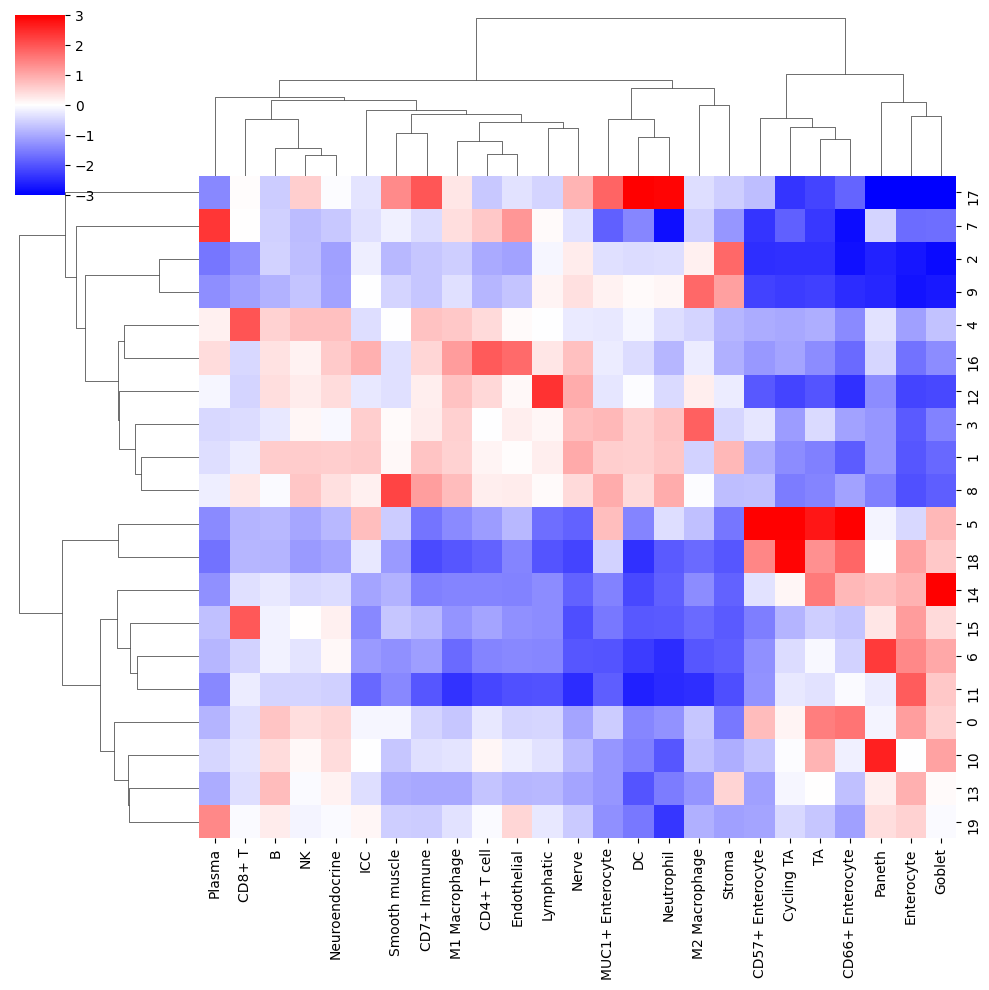

In [22]:
# Select the centroids for a specific value of 'k' for plotting
k_to_plot = k
niche_clusters = (k_centroids3[k_to_plot])

# Calculate the average cell types across the 'values' array
tissue_avgs = values3.mean(axis=0)

# Compute fold change (fc) of cell types abundance within a neighborhood versus that in the tissue
# This involves a log2 transformation of the ratio of (niche_clusters + tissue_avgs) to tissue_avgs
# The ratio is normalized by the sum across each row (axis=1), ensuring that the sum of ratios for each row is 1
fc = np.log2(((niche_clusters + tissue_avgs) / (niche_clusters + tissue_avgs).sum(axis=1, keepdims=True)) / tissue_avgs)

# Convert the fold change array into a pandas DataFrame for each cell type
fc = pd.DataFrame(fc, columns=sum_cols3)

# Create a clustered heatmap using seaborn's clustermap function
# 'fc' DataFrame is used as input
# vmin and vmax set the color scale limits for the heatmap (-3 to 3 in this case)
# cmap='bwr' sets the color palette to blue-white-red
# figsize=(10,10) sets the size of the heatmap
s = sns.clustermap(fc, vmin=-3, vmax=3, cmap='bwr', figsize=(10,10))

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import matplotlib.patches as mpatches

# ========== 全局变量记录第一次的顺序、颜色与参考特征 ========== #
clustermap_col_order = None
cluster_color_dict = {}
base_fc = None
base_max_idx = None  # 保存第一次每个 cluster 最大值对应的列索引

def run_and_plot_neighborhood_clustering1(k, windows2, sum_cols, values, cells, is_first_run=False):
    global clustermap_col_order, cluster_color_dict, base_fc, base_max_idx

    n_neighborhoods = k
    neighborhood_name = f"neighborhood{k}"

    # Step 1: clustering
    km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)
    labels = km.fit_predict(windows2[sum_cols].values)
    cells[neighborhood_name] = labels
    niche_clusters = km.cluster_centers_

    # Step 2: fold change
    tissue_avgs = values.mean(axis=0)
    fc = np.log2(
        ((niche_clusters + tissue_avgs) / (niche_clusters + tissue_avgs).sum(axis=1, keepdims=True))
        / tissue_avgs
    )
    fc = pd.DataFrame(fc, columns=sum_cols)

    if is_first_run:
        # === 第一次运行：聚类并确定列顺序 === #
        g = sns.clustermap(
            fc,
            vmin=-3, vmax=3,
            cmap='bwr',
            figsize=(10, 10),
            col_cluster=True,
            row_cluster=True,
            xticklabels=True,
            yticklabels=False,
            dendrogram_ratio=(0, 0),
            cbar_pos=None
        )

        reordered_cols = g.dendrogram_col.reordered_ind
        clustermap_col_order = fc.columns[reordered_cols].tolist()

        reordered_rows = g.dendrogram_row.reordered_ind
        base_fc = fc.iloc[reordered_rows].copy().reset_index(drop=True)
        base_max_idx = base_fc.values.argmax(axis=1)

        colors = sns.color_palette("husl", len(reordered_rows))
        cluster_color_dict = {i: colors[i] for i in range(len(reordered_rows))}

        handles = [mpatches.Patch(color=cluster_color_dict[i], label=f"Cluster {i}") for i in range(len(reordered_rows))]
        plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

        plt.title(f"Neighborhood Clustering (k={k}) [Base Run]")
        plt.show()
        return niche_clusters

    else:
        # === 后续运行：固定列顺序，不再重新聚类列 === #
        fc = fc[clustermap_col_order]

        g = sns.clustermap(
            fc,
            vmin=-3, vmax=3,
            cmap='bwr',
            figsize=(10, 10),
            col_cluster=False,  # 不重新聚类列
            row_cluster=True,
            xticklabels=True,
            yticklabels=False,
            dendrogram_ratio=(0, 0),
            cbar_pos=None
        )

        handles = [mpatches.Patch(color=cluster_color_dict[i], label=f"Base Cluster {i}") for i in cluster_color_dict]
        plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.title(f"Neighborhood Clustering (k={k}) [Aligned to Base]")
        plt.show()


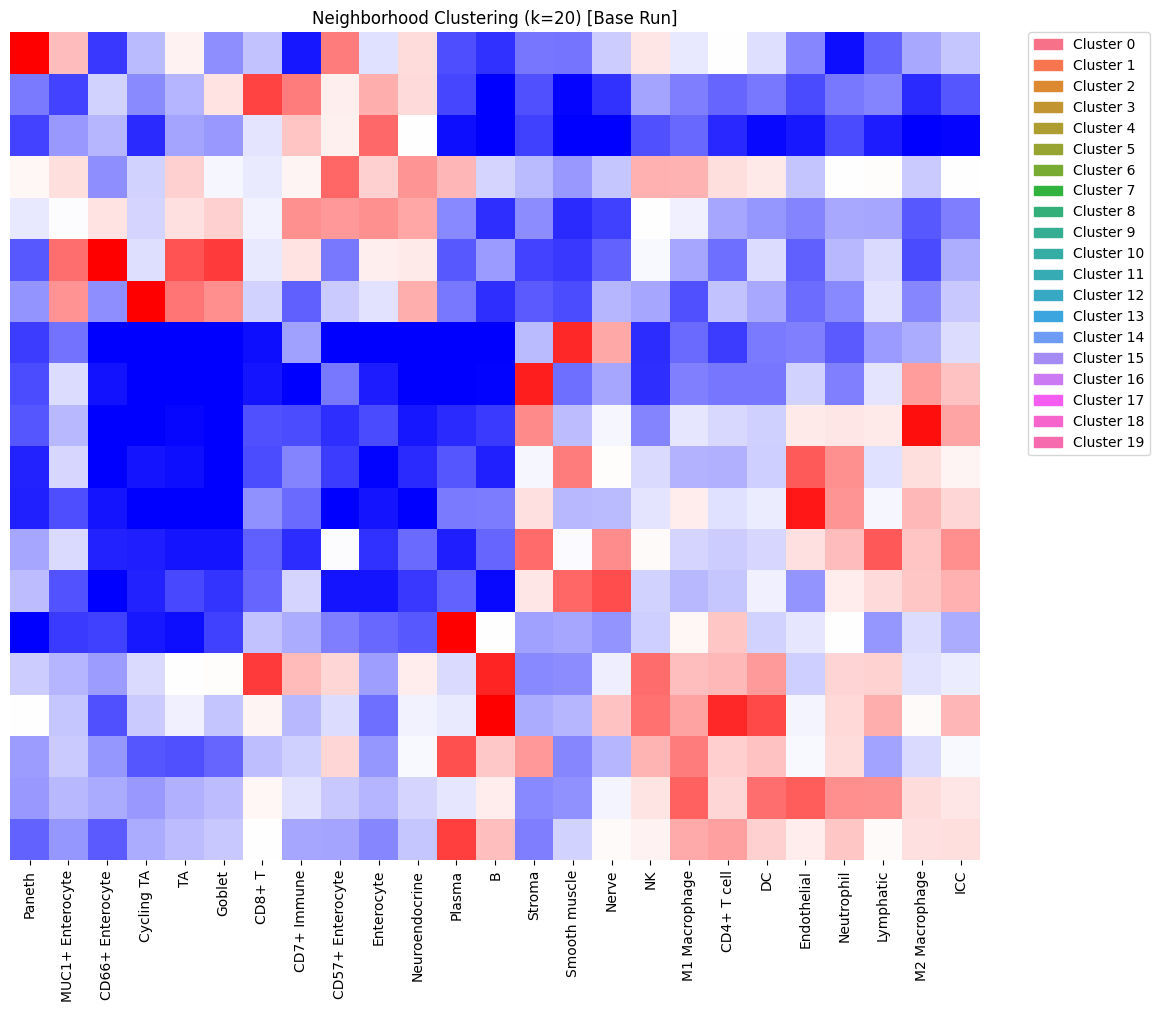

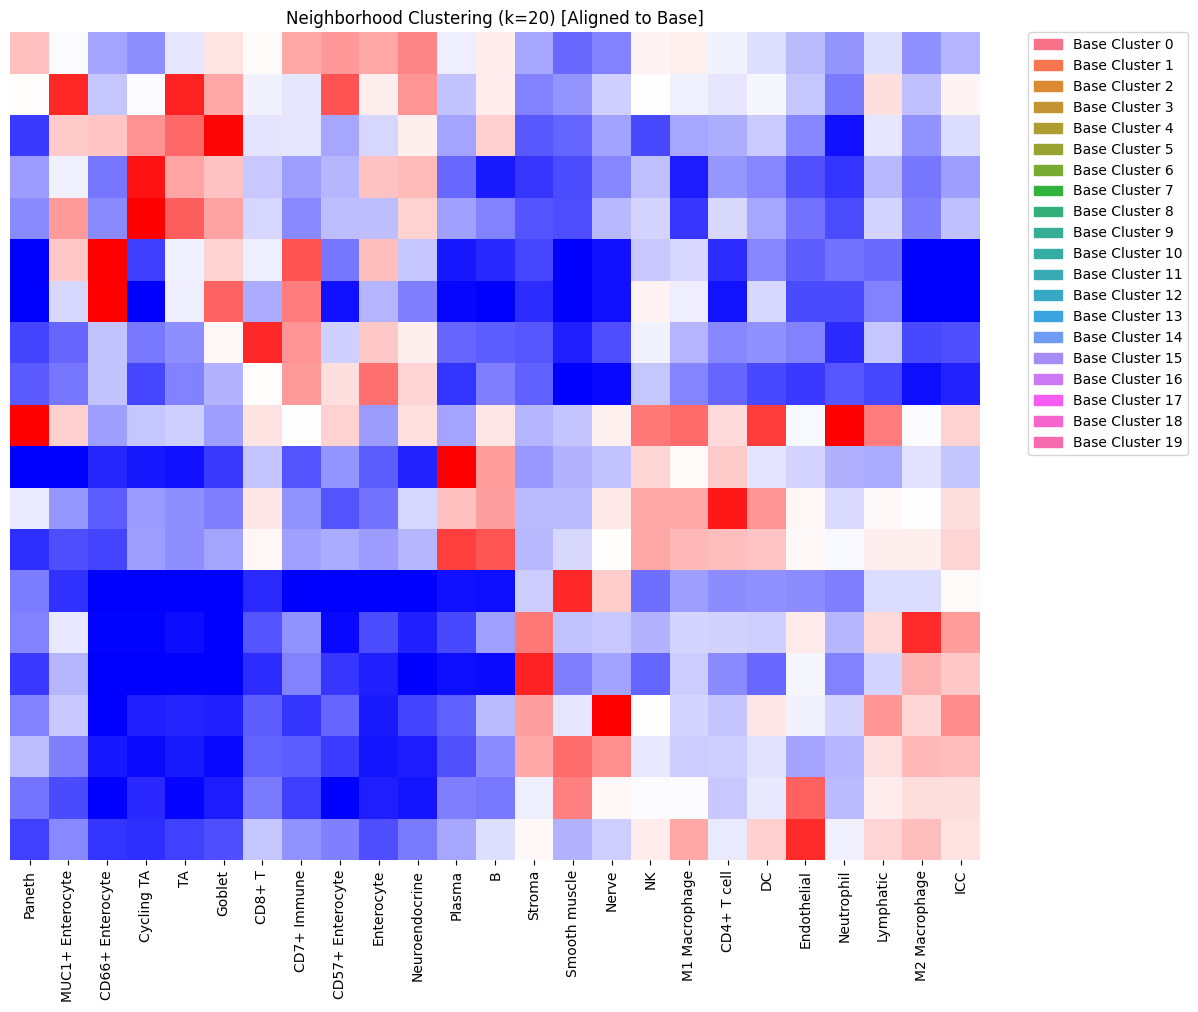

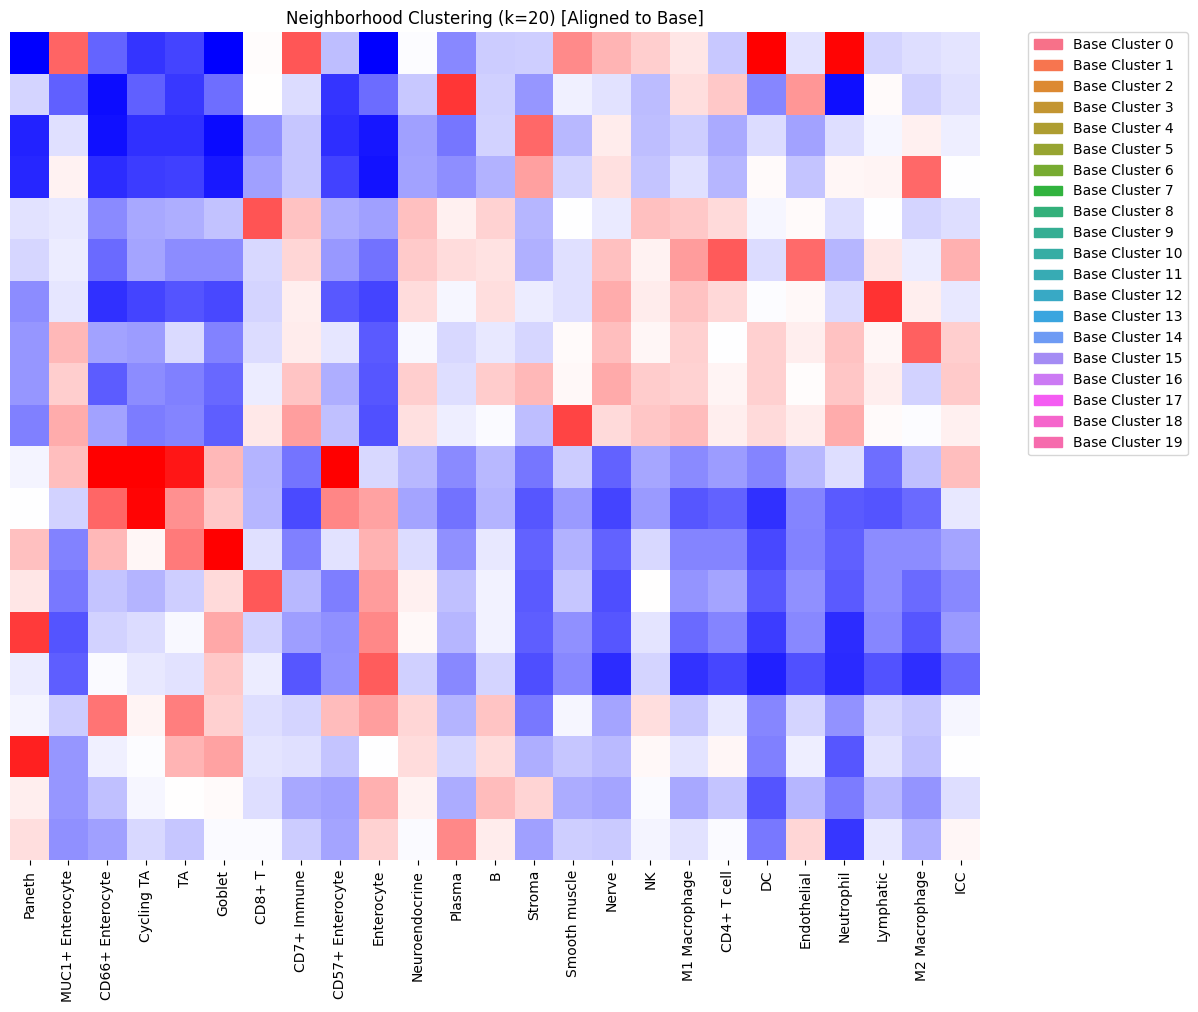

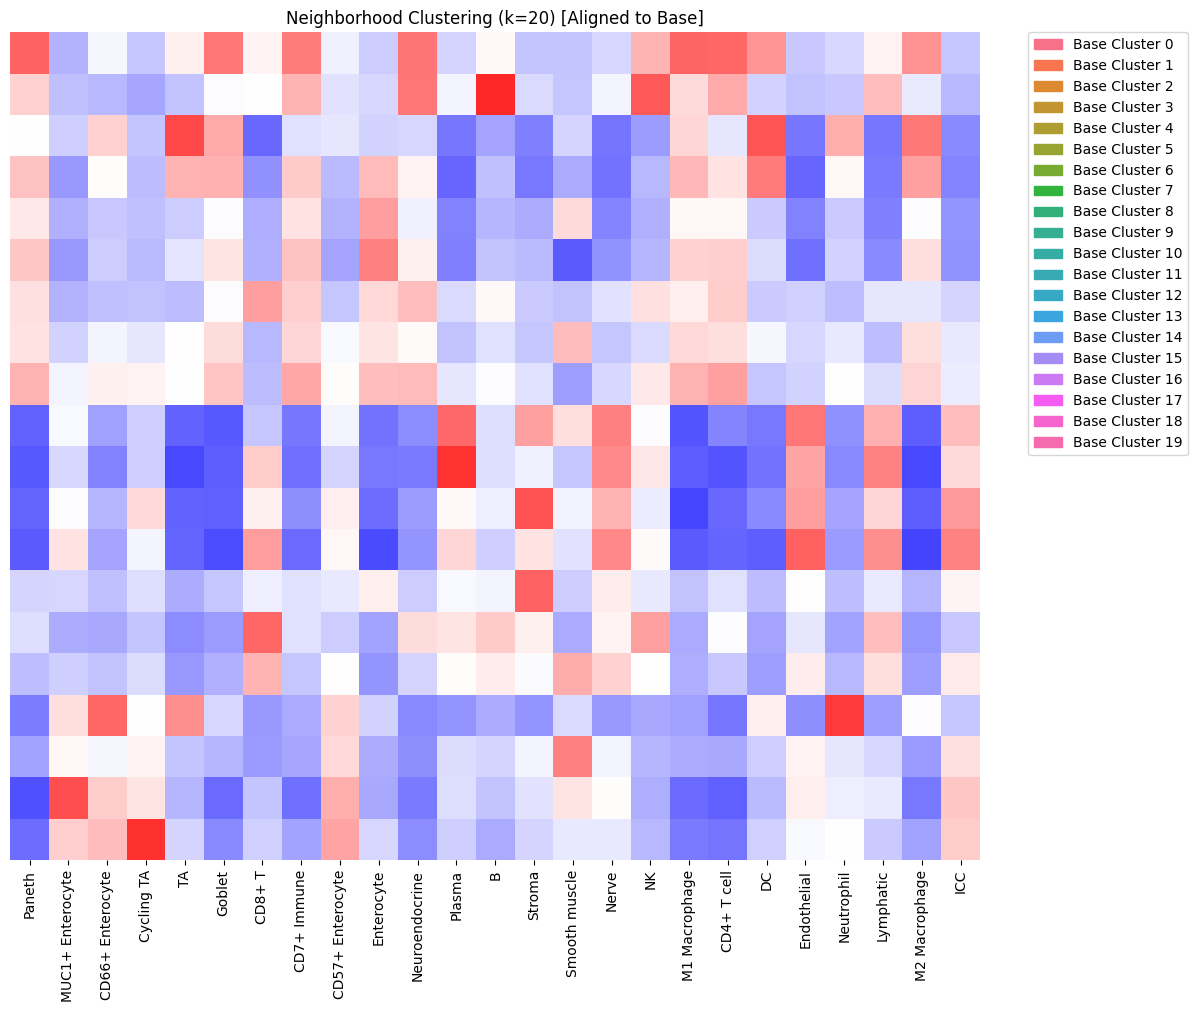

In [31]:
# 第一次运行：建立列顺序
true_niche_clusters = run_and_plot_neighborhood_clustering1(
    k=20,
    windows2=windows2_1,
    sum_cols=sum_cols1,
    values=values1,
    cells=cells1,
    is_first_run=True
)

# 后续运行：固定列顺序
run_and_plot_neighborhood_clustering1(k=20, windows2=windows2_2, sum_cols=sum_cols2, values=values2, cells=cells2)
run_and_plot_neighborhood_clustering1(k=20, windows2=windows2_3, sum_cols=sum_cols3, values=values3, cells=cells3)
run_and_plot_neighborhood_clustering1(k=20, windows2=windows2_4, sum_cols=sum_cols4, values=values4, cells=cells4)


In [32]:
print(true_niche_clusters)

[[3.33756575e-02 8.62144023e-01 6.87647379e-01 2.59604571e+00
  3.60420824e-01 3.71848358e-02 6.54815890e-01 4.04135679e-01
  3.27226555e-01 6.23979684e-02 1.27879557e-01 9.77689098e-02
  1.05024488e-01 1.36767640e-01 2.69580990e+00 6.58443679e-02
  7.49138400e-02 3.84545619e-02 2.75530564e-01 4.04498458e-02
  1.83203338e-02 2.12588427e-01 4.49845819e-02 2.30364593e-02
  1.72319971e-02]
 [9.95689655e-02 4.76226054e+00 1.10919540e-01 1.76005747e-01
  3.31379310e+00 2.58620690e-02 9.29597701e-02 5.53639847e-02
  4.36302682e-02 9.27681992e-02 2.75383142e-02 5.70881226e-01
  7.72988506e-02 2.65325670e-02 8.71168582e-02 1.18869732e-01
  1.36494253e-01 7.61494253e-03 2.51436782e-02 8.14176245e-04
  8.65900383e-02 3.30938697e-02 9.86590038e-03 5.07662835e-03
  1.39367816e-02]
 [7.55382097e-03 5.05266692e-02 2.12723992e-01 5.56254983e-01
  3.61324437e-02 1.17923539e-02 5.24570901e-02 8.02047925e+00
  2.07939905e-01 7.13416425e-04 5.34013177e-01 5.87519409e-03
  9.74023249e-02 1.06676738e-01 1.

In [ ]:
cluster_color_dict

{18: (0.962272393509669, 0.3976451968965351, 0.8008274363432775),
 1: (0.9704241569984234, 0.4603475375001678, 0.3099359864545268),
 7: (0.19316929744982803, 0.7018418078239693, 0.24321388407365968),
 13: (0.22829030785596155, 0.6480515334381642, 0.8744997507366618),
 14: (0.433280341176423, 0.6065273407962815, 0.9585467098271748),
 5: (0.5920891529639701, 0.6418467016378244, 0.1935069134991043),
 11: (0.21461147568939787, 0.6708637556281021, 0.7042594890626992),
 2: (0.8616090647292522, 0.536495730113334, 0.19548899031476086),
 10: (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 16: (0.8004936186423958, 0.47703363533737203, 0.9579547196007522),
 9: (0.20631516405196249, 0.6834948167725491, 0.5761817437653648),
 17: (0.9579148533500138, 0.358831186992106, 0.9474115985773391),
 15: (0.6423044349219739, 0.5497680051256467, 0.9582651433656727),
 19: (0.9651791951613143, 0.4212549802305815, 0.6785112441648762),
 8: (0.20125317221201128, 0.6907920815379025, 0.479667611892753

In [27]:
def get_cluster_signatures(fc_df, use_min=False):
    """
    给每个 cluster 找 signature cell type = fc 最大(或最小)的列
    返回 {cluster_idx : cell_type_name}
    """
    signatures = {}
    for i, row in fc_df.iterrows():
        if use_min:
            signatures[i] = row.idxmin()
        else:
            signatures[i] = row.idxmax()
    return signatures

def run_and_plot_neighborhood_clustering(k, windows2, sum_cols, values, cells, is_first_run=False, use_min=False):
    global clustermap_col_order, clustermap_row_order, cluster_color_dict, true_niche_clusters, true_signatures

    n_neighborhoods = k
    neighborhood_name = f"neighborhood{k}"

    # Step 1: clustering
    km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)
    labels = km.fit_predict(windows2[sum_cols].values)
    cells[neighborhood_name] = labels
    niche_clusters = km.cluster_centers_

    # Step 2: fold change
    tissue_avgs = values.mean(axis=0)
    fc = np.log2(((niche_clusters + tissue_avgs) / (niche_clusters + tissue_avgs).sum(axis=1, keepdims=True)) / tissue_avgs)
    fc = pd.DataFrame(fc, columns=sum_cols)

    if is_first_run:
        true_niche_clusters = niche_clusters.copy()
        true_signatures = get_cluster_signatures(fc, use_min=use_min)  # 保存 signature

        # ====== 初始聚类 + 记录顺序 + 分配颜色 ====== #
        g = sns.clustermap(
            fc,
            vmin=-3, vmax=3,
            cmap='bwr',
            figsize=(10, 10),
            col_cluster=True,
            row_cluster=True,
            xticklabels=True,
            yticklabels=False,
            dendrogram_ratio=(0, 0),
            cbar_pos=None
        )

        reordered_cols = g.dendrogram_col.reordered_ind
        reordered_rows = g.dendrogram_row.reordered_ind
        clustermap_col_order = fc.columns[reordered_cols].tolist()
        clustermap_row_order = reordered_rows

        # 分配颜色（差异大）
        colors = sns.color_palette("tab20", len(reordered_rows))
        cluster_color_dict = {i: colors[j] for j, i in enumerate(reordered_rows)}

        row_colors_df = pd.DataFrame([cluster_color_dict[i] for i in reordered_rows],
                                     columns=['r', 'g', 'b'])

        plt.close('all')
        g = sns.clustermap(
            fc.iloc[reordered_rows][clustermap_col_order],
            vmin=-3, vmax=3,
            cmap='bwr',
            figsize=(10, 10),
            col_cluster=False,
            row_cluster=False,
            xticklabels=True,
            yticklabels=False,
            row_colors=row_colors_df.values,
            dendrogram_ratio=(0, 0),
            cbar_pos=None
        )
        g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)

        handles = [mpatches.Patch(color=cluster_color_dict[i],
                                  label=f"Cluster {i} ({true_signatures[i]})")
                   for i in reordered_rows]
        plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.title(f"Neighborhood Clustering (k={k}) - First Run")
        plt.show()

    else:
        # 新的 signatures
        new_signatures = get_cluster_signatures(fc, use_min=use_min)

        # 构建映射：旧 cluster -> 新 cluster
        mapping_old_to_new = {}
        used_new = set()
        for old_idx, old_sig in true_signatures.items():
            # 先找完全相同的
            matches = [new for new, sig in new_signatures.items() if sig == old_sig and new not in used_new]
            if matches:
                mapping_old_to_new[old_idx] = matches[0]
                used_new.add(matches[0])
            else:
                # 如果找不到完全相同，就找最接近的 cluster
                diffs = {new: abs(fc.loc[new, old_sig]) for new in new_signatures if new not in used_new}
                best_new = min(diffs, key=diffs.get)
                mapping_old_to_new[old_idx] = best_new
                used_new.add(best_new)

        # 保证顺序和第一次一致
        new_order = [mapping_old_to_new[old] for old in clustermap_row_order]

        fc = fc[clustermap_col_order]
        fc = fc.iloc[new_order]

        row_colors_df = pd.DataFrame([cluster_color_dict[old] for old in clustermap_row_order],
                                     columns=['r', 'g', 'b'])

        g = sns.clustermap(
            fc,
            vmin=-3, vmax=3,
            cmap='bwr',
            figsize=(10, 10),
            col_cluster=False,
            row_cluster=False,
            xticklabels=True,
            yticklabels=False,
            row_colors=row_colors_df.values,
            dendrogram_ratio=(0, 0),
            cbar_pos=None
        )

        g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                                     rotation=45, ha='right', fontsize=12)

        handles = [mpatches.Patch(color=cluster_color_dict[old],
                                  label=f"Cluster {old} ({true_signatures[old]})")
                   for old in clustermap_row_order]
        plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.title(f"Neighborhood Clustering (k={k}) - Signature Matched")
        plt.show()


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def assign_cells_to_clusters(csv_path, niche_clusters, cluster_color_dict, k_neigh=20):
    """
    给定一个 cell type map 的 CSV 文件，为每个 cell 指派最相似的 cluster，并赋予颜色。
    使用最近的 k 个邻居构建 neighborhood 向量。
    """

    # ========== Step 1: 读取 cell 数据 ==========
    df = pd.read_csv(csv_path)

    df.columns = [col.strip().lower() for col in df.columns]
    print(df.columns)
    assert set(['x', 'y', 'cell type']).issubset(df.columns), "CSV 必须包含 x, y, type 列"

    # ========== Step 2: 构建 neighborhood 表征 ==========
    coords = df[['x', 'y']].values
    types = df['cell type'].values
    unique_types = sorted(df['cell type'].unique())
    type_to_idx = {t: i for i, t in enumerate(unique_types)}
    types = df['cell type'].map(type_to_idx).values.astype(int)
    num_cells = len(df)
    num_types = niche_clusters.shape[1]

    neighborhood_features = np.zeros((num_cells, num_types))

    print("构建 neighborhood vector 中（最近邻法）...")

    for i in range(num_cells):
        xi = coords[i]
        dists = np.linalg.norm(coords - xi, axis=1)
        nearest_idx = np.argsort(dists)[1:k_neigh+1]  # 跳过自己，选最近 k 个
        neighbor_types = types[nearest_idx]
        counts = np.bincount(neighbor_types, minlength=num_types)
        neighborhood_features[i] = counts / counts.sum()

    # ========== Step 3: 匹配最近 cluster ==========
    print("寻找最近 cluster 中...")

    dists_to_centroids = cdist(neighborhood_features, niche_clusters, metric='euclidean')
    closest_clusters = np.argmin(dists_to_centroids, axis=1)

    df['cluster'] = closest_clusters

    # ========== Step 4: 赋颜色 ==========
    print("映射颜色中...")

    color_array = np.array([cluster_color_dict[c] for c in closest_clusters])
    df['R'] = (color_array[:, 0] * 255).astype(np.uint8)
    df['G'] = (color_array[:, 1] * 255).astype(np.uint8)
    df['B'] = (color_array[:, 2] * 255).astype(np.uint8)

    # ========== Step 5: 画图 ==========
    print("绘图中...")

    plt.figure(figsize=(8, 8))
    plt.scatter(df['x'], df['y'], color=color_array, s=1)
    plt.axis('equal')
    plt.title("Cluster-colored Cell Map")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

    return df


Index(['cell type', 'x', 'y', 'unique_region'], dtype='object')
构建 neighborhood vector 中（最近邻法）...
寻找最近 cluster 中...
映射颜色中...
绘图中...


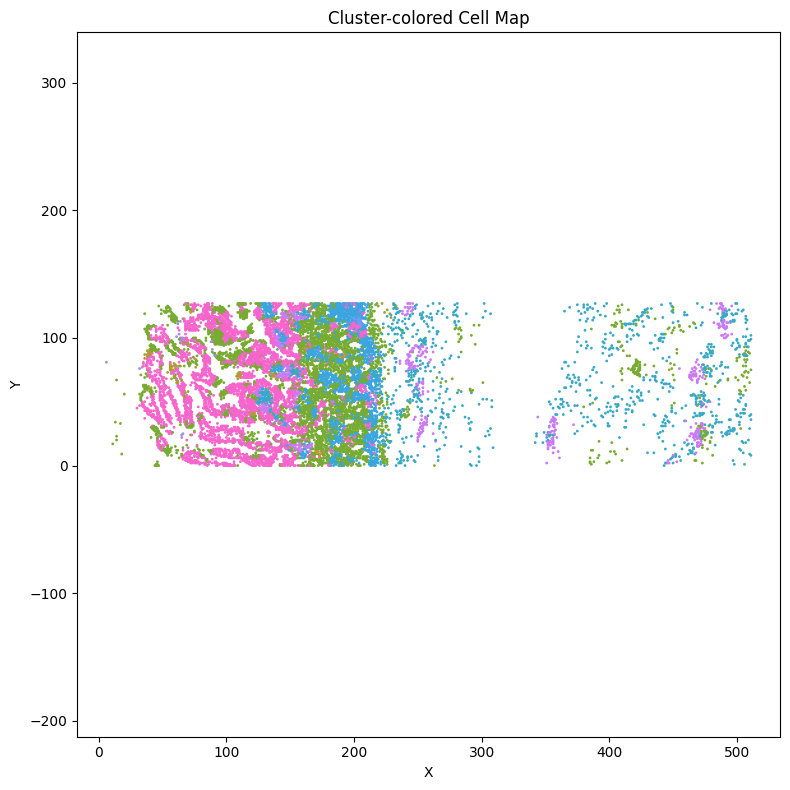

Index(['cell type', 'x', 'y', 'unique_region'], dtype='object')
构建 neighborhood vector 中（最近邻法）...
寻找最近 cluster 中...
映射颜色中...
绘图中...


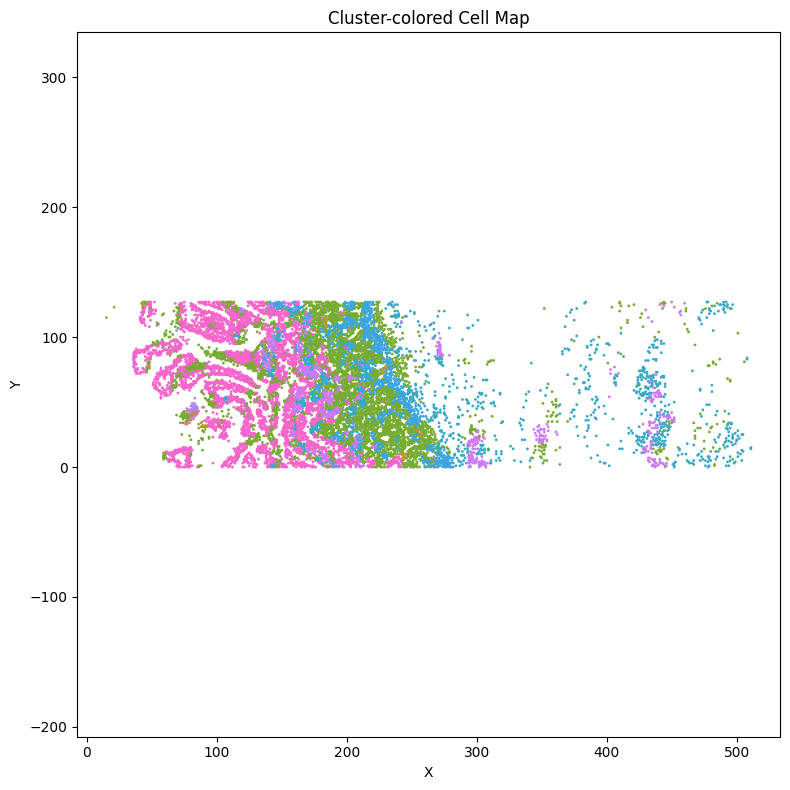

Index(['cell type', 'x', 'y', 'unique_region'], dtype='object')
构建 neighborhood vector 中（最近邻法）...
寻找最近 cluster 中...
映射颜色中...
绘图中...


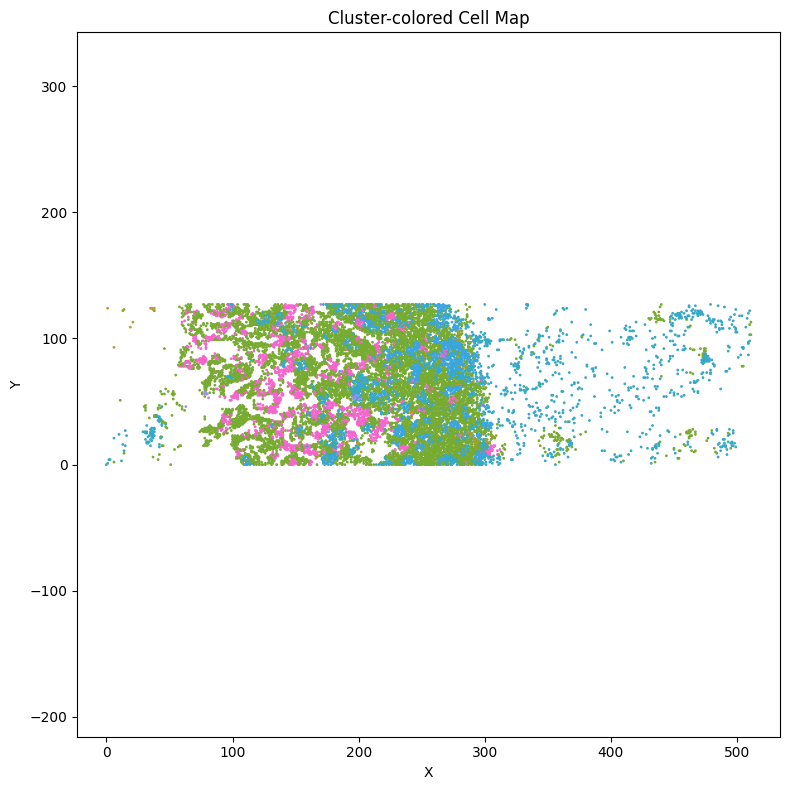

Index(['cell type', 'x', 'y', 'unique_region'], dtype='object')
构建 neighborhood vector 中（最近邻法）...
寻找最近 cluster 中...
映射颜色中...
绘图中...


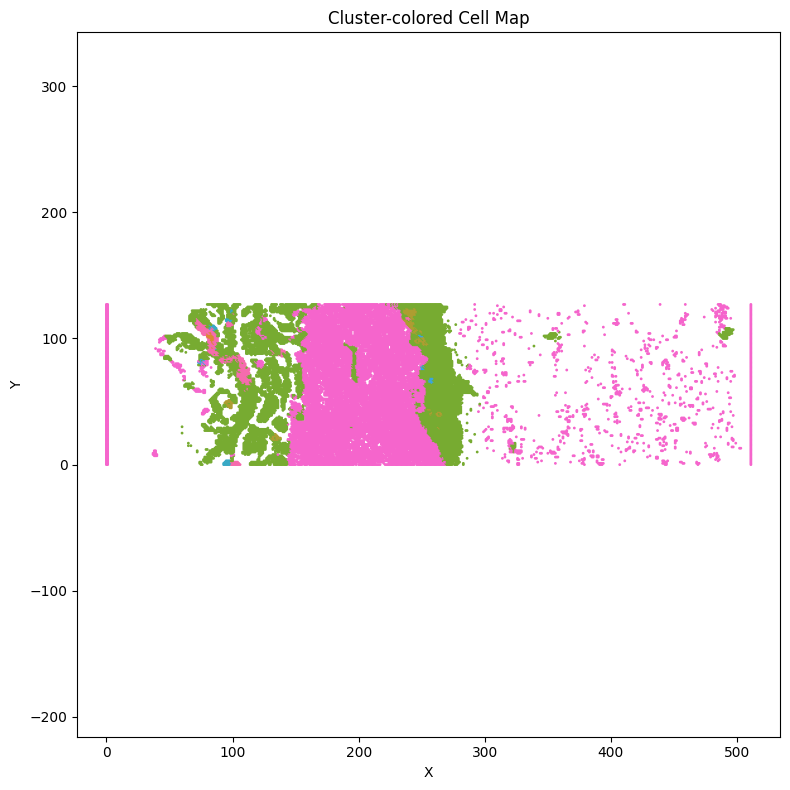

In [42]:
normalized_clusters = true_niche_clusters / true_niche_clusters.sum(axis=1, keepdims=True)
df_colored = assign_cells_to_clusters(
    csv_path=f"drive/MyDrive/bottom/21.csv",
    niche_clusters=normalized_clusters,
    cluster_color_dict=cluster_color_dict,
    k_neigh=20  # 最近20个邻居
)
df_colored = assign_cells_to_clusters(
    csv_path=f"drive/MyDrive/top/21.csv",
    niche_clusters=normalized_clusters,
    cluster_color_dict=cluster_color_dict,
    k_neigh=20  # 最近20个邻居
)
df_colored = assign_cells_to_clusters(
    csv_path=f"drive/MyDrive/new/21.csv",
    niche_clusters=normalized_clusters,
    cluster_color_dict=cluster_color_dict,
    k_neigh=20  # 最近20个邻居
)
df_colored = assign_cells_to_clusters(
    csv_path=f"21.csv",
    niche_clusters=normalized_clusters,
    cluster_color_dict=cluster_color_dict,
    k_neigh=20  # 最近20个邻居
)
